# Feature Split Analysis

This notebook analyses the contents that `CombinedMetadataUtils` exposes:

1. **HUNT EDA** — distributions of the raw cleaned health features.
2. **Normalisation analysis** — verify `HealthDataLoader.generate_normalized()` produces the right shape per feature type.
3. **Feature-based split** — using `data/metadata/splits.json`, check the train / val / test split keeps similar distributions across features.

All feature types are classified by *column name* (matching the source-data spec):

- **Binary**:      `Sex`, `DiaEv@NT3BLQ1`, `WorCu@NT3BLI`
- **Categorical**: `Healt@NT3BLQ1`, `SmoStat@NT3BLQ1`, `Educ@NT2BLQ1`
- **Numerical**:   `BirthYear`, `SmoPackYrs@NT3BLQ1`, `WaistCirc@NT3BLM`, `HipCirc@NT3BLM`, `BPDiasMn23@NT3BLM`, `BPSystMn23@NT3BLM`, `SeGluNonFast@NT3BLM`, `Bmi@NT3BLM`, `HADSTotExtr@NT3BLQ2`

## Setup

In [87]:
import sys, json
sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from utils.metadata.combined_metadata_utils import CombinedMetadataUtils

In [88]:
import os

RAW_PATH    = 'data/metadata/health_data/health_data.csv'
NORM_PATH   = 'data/metadata/processed/health_data_normalized.csv'
SPLITS_PATH = 'data/metadata/splits.json'

FIG_DIR = 'out/overleaf_figures/stats'
os.makedirs(FIG_DIR, exist_ok=True)

# Column classification (matches HealthDataLoader.{NUMERICAL,CATEGORICAL,BINARY,DROP}_COLS)
CONTINUOUS  = ['BirthYear', 'SmoPackYrs@NT3BLQ1', 'WaistCirc@NT3BLM', 'HipCirc@NT3BLM',
               'BPDiasMn23@NT3BLM', 'BPSystMn23@NT3BLM', 'SeGluNonFast@NT3BLM',
               'Bmi@NT3BLM', 'HADSTotExtr@NT3BLQ2']
CATEGORICAL = ['Healt@NT3BLQ1', 'SmoStat@NT3BLQ1', 'Educ@NT2BLQ1']
BINARY      = ['Sex', 'DiaEv@NT3BLQ1', 'WorCu@NT3BLI']
ALL_VARS    = CONTINUOUS + CATEGORICAL + BINARY
DROP_COLS   = ['PID@115827', 'Part@NT2BLQ1', 'Part@NT3BLI', 'Part@NT3BLM',
               'Part@NT3BLQ1', 'Part@NT3BLQ2']

with open(SPLITS_PATH) as f:
    _splits = json.load(f)
SEED        = _splits['seed']
TRAIN_SPLIT = _splits['train_split']
VAL_SPLIT   = _splits['val_split']

SPLIT_NAMES  = ['Train', 'Validation', 'Test']
SPLIT_COLORS = ['steelblue', 'darkorange', 'seagreen']


---
## Part 1 — HUNT External Data EDA

In [89]:
raw  = pd.read_csv(RAW_PATH).drop(columns=DROP_COLS, errors='ignore')
norm = pd.read_csv(NORM_PATH)

# Sex in raw is 1 for Male, NaN for Female — make it explicit for EDA
raw['Sex'] = raw['Sex'].fillna(0).astype(int)

# Defensive: the normalised CSV contains a stray non-numeric value
# ('wa') in HADSTotExtr@NT3BLQ2, forcing the column to object dtype.
# Coerce continuous columns to numeric so downstream .mean()/.hist() work.
for _c in CONTINUOUS:
    if _c in norm.columns:
        norm[_c] = pd.to_numeric(norm[_c], errors='coerce')

print(f"Raw  : {raw.shape[0]} subjects × {raw.shape[1]} features")
print(f"Norm : {norm.shape[0]} subjects × {norm.shape[1]-1} feature columns "
      f"(categoricals one-hot encoded)")
display(raw.head(5))


Raw  : 772 subjects × 15 features
Norm : 772 subjects × 27 feature columns (categoricals one-hot encoded)


,Sex,BirthYear,DiaEv@NT3BLQ1,Healt@NT3BLQ1,SmoStat@NT3BLQ1,SmoPackYrs@NT3BLQ1,WaistCirc@NT3BLM,HipCirc@NT3BLM,BPDiasMn23@NT3BLM,BPSystMn23@NT3BLM,SeGluNonFast@NT3BLM,Bmi@NT3BLM,WorCu@NT3BLI,Educ@NT2BLQ1,HADSTotExtr@NT3BLQ2
0,0,1954,0,3,0,0.0,71,98,68,107,5.0,23.6,1,5,4.0
1,0,1944,0,3,1,15.0,74,94,70,139,5.6,21.9,1,1,0.0
2,0,1948,0,3,0,0.0,84,99,56,113,3.3,21.8,1,5,1.0
3,0,1944,0,3,1,1.0,84,101,83,128,5.2,25.6,1,2,4.0
4,0,1951,0,3,0,0.0,76,103,67,121,5.4,27.1,1,3,1.0


### Variable overview

In [90]:
rows = []
for col in ALL_VARS:
    kind = ('Continuous' if col in CONTINUOUS
            else 'Binary'      if col in BINARY
            else 'Categorical')
    rows.append({
        'Variable': col,
        'Type':     kind,
        'N unique': raw[col].nunique(dropna=False),
        'Missing':  int(raw[col].isna().sum()),
        'Values / range': (
            f"{raw[col].min():.2f} – {raw[col].max():.2f}" if col in CONTINUOUS
            else str(sorted(raw[col].dropna().unique().tolist()))
        ),
    })
display(pd.DataFrame(rows).set_index('Variable'))

,Type,N unique,Missing,Values / range
Variable,,,,
BirthYear,Continuous,17,0,1941.00 – 1957.00
SmoPackYrs@NT3BLQ1,Continuous,207,0,0.00 – 57.50
WaistCirc@NT3BLM,Continuous,60,0,61.00 – 132.00
HipCirc@NT3BLM,Continuous,41,0,80.00 – 125.00
BPDiasMn23@NT3BLM,Continuous,61,0,48.00 – 120.00
BPSystMn23@NT3BLM,Continuous,88,0,91.00 – 201.00
SeGluNonFast@NT3BLM,Continuous,74,0,0.00 – 26.80
Bmi@NT3BLM,Continuous,158,0,18.30 – 39.40
HADSTotExtr@NT3BLQ2,Continuous,38,76,0.00 – 33.00


### Continuous variables 

In [91]:
stats = raw[CONTINUOUS].agg(['min','max','mean','median','std','var']).round(3)
display(stats.T.rename(columns=str.title))

,Min,Max,Mean,Median,Std,Var
BirthYear,1941.0,1957.0,1949.624,1949.0,4.181,17.480
SmoPackYrs@NT3BLQ1,0.0,57.5,7.264,1.5,10.210,104.252
WaistCirc@NT3BLM,61.0,132.0,92.608,93.0,10.164,103.305
HipCirc@NT3BLM,80.0,125.0,102.780,103.0,6.551,42.914
BPDiasMn23@NT3BLM,48.0,120.0,76.123,76.0,10.613,112.627
BPSystMn23@NT3BLM,91.0,201.0,131.280,130.0,16.730,279.890
SeGluNonFast@NT3BLM,0.0,26.8,5.290,5.2,2.135,4.557
Bmi@NT3BLM,18.3,39.4,26.858,26.6,3.514,12.347
HADSTotExtr@NT3BLQ2,0.0,33.0,6.603,5.7,5.129,26.309


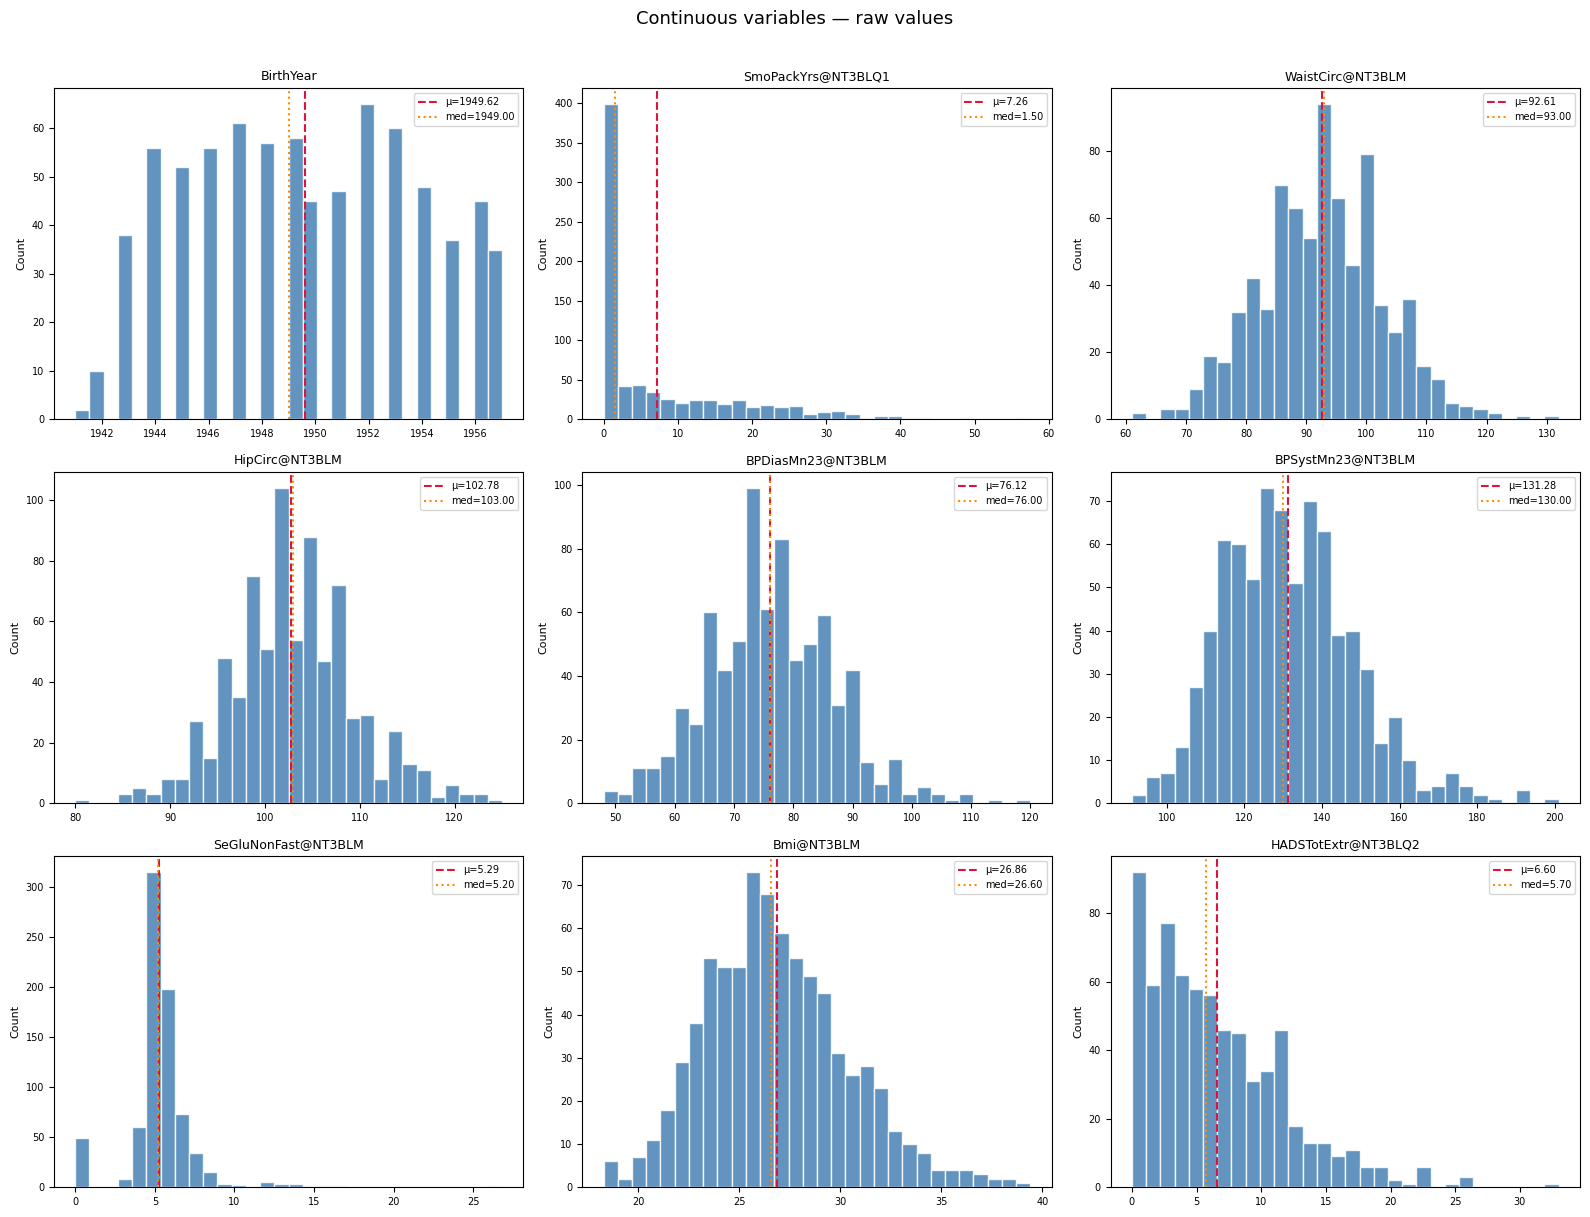

In [92]:
ncols = 3
nrows = (len(CONTINUOUS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
for ax, col in zip(axes.flat, CONTINUOUS):
    data = raw[col].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='crimson',    linestyle='--', lw=1.5,
               label=f'μ={data.mean():.2f}')
    ax.axvline(data.median(), color='darkorange', linestyle=':',  lw=1.5,
               label=f'med={data.median():.2f}')
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('Count', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(CONTINUOUS):]:
    ax.set_visible(False)
plt.suptitle('Continuous variables — raw values', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_continuous_hist.png', dpi=150, bbox_inches='tight')
plt.show()

### Categorical & binary variables — distributions

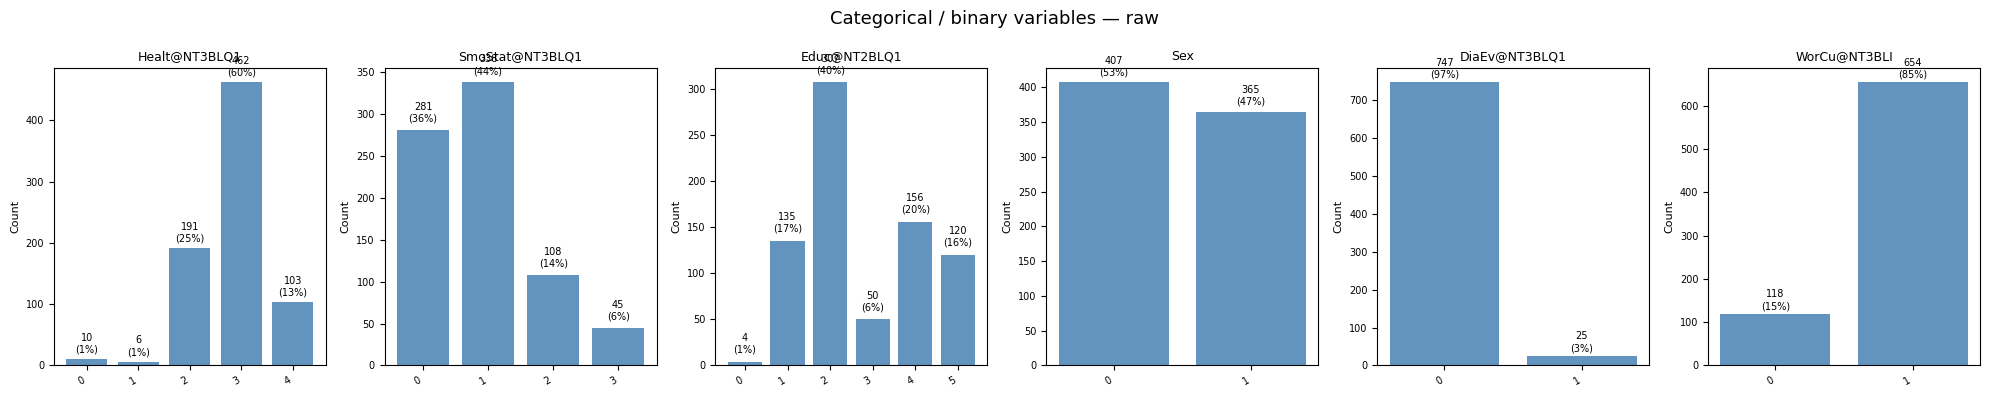

In [93]:
ALL_CAT = CATEGORICAL + BINARY
fig, axes = plt.subplots(1, len(ALL_CAT), figsize=(20, 4))
for ax, col in zip(axes, ALL_CAT):
    vc = raw[col].dropna().value_counts().sort_index()
    bars = ax.bar(range(len(vc)), vc.values, color='steelblue', alpha=0.85)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels([str(v) for v in vc.index], rotation=30, ha='right', fontsize=8)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('Count', fontsize=8)
    total = vc.sum()
    for bar, count in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
                f'{count}\n({count/total*100:.0f}%)',
                ha='center', va='bottom', fontsize=7)
    ax.tick_params(labelsize=7)
plt.suptitle('Categorical / binary variables — raw', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_categorical_binary_bars.png', dpi=150, bbox_inches='tight')
plt.show()

In [94]:
for col in CATEGORICAL + BINARY:
    vc = raw[col].dropna().value_counts().sort_index()
    pct = (vc / vc.sum() * 100).round(1)
    tbl = pd.concat([vc, pct], axis=1, keys=['Count','%'])
    tbl.index.name = col
    display(tbl)

,Count,%
Healt@NT3BLQ1,,
0,10,1.3
1,6,0.8
2,191,24.7
3,462,59.8
4,103,13.3


,Count,%
SmoStat@NT3BLQ1,,
0,281,36.4
1,338,43.8
2,108,14.0
3,45,5.8


,Count,%
Educ@NT2BLQ1,,
0,4,0.5
1,135,17.5
2,307,39.8
3,50,6.5
4,156,20.2
5,120,15.5


,Count,%
Sex,,
0,407,52.7
1,365,47.3


,Count,%
DiaEv@NT3BLQ1,,
0,747,96.8
1,25,3.2


,Count,%
WorCu@NT3BLI,,
0,118,15.3
1,654,84.7


---
## Part 2 — Normalisation

`HealthDataLoader.generate_normalized()` classifies columns by name:

- **Continuous** → min-max scaled to **[0, 1]** (shape unchanged, range compressed).
- **Binary** → cast to int **0 / 1** (`Sex` treats `1` = Male, missing/[NONE] = Female).
- **Categorical** → **one-hot encoded** into `<col>_<level>` indicator columns.

The cells below verify each transformation against the raw data.

### Column mapping

In [95]:
norm_feat_cols = [c for c in norm.columns if c != 'hunt_id']

# Build one-hot groups dynamically from norm column names
ohe_groups = {}
for cat in CATEGORICAL:
    ohe_groups[cat] = [c for c in norm_feat_cols if c.startswith(cat + '_')]

rows = []
for col in ALL_VARS:
    if col in CONTINUOUS:
        rows.append({'Raw column': col, 'Transformation': 'min-max → [0, 1]',
                     'Normalised column(s)': col})
    elif col in BINARY:
        rows.append({'Raw column': col, 'Transformation': 'binary (0 / 1)',
                     'Normalised column(s)': col})
    else:
        ohe = ohe_groups[col]
        rows.append({'Raw column': col,
                     'Transformation': f'one-hot ({len(ohe)} levels)',
                     'Normalised column(s)': ', '.join(
                         c.replace(col + '_','') for c in ohe)})

display(pd.DataFrame(rows).set_index('Raw column'))

,Transformation,Normalised column(s)
Raw column,,
BirthYear,"min-max → [0, 1]",BirthYear
SmoPackYrs@NT3BLQ1,"min-max → [0, 1]",SmoPackYrs@NT3BLQ1
WaistCirc@NT3BLM,"min-max → [0, 1]",WaistCirc@NT3BLM
HipCirc@NT3BLM,"min-max → [0, 1]",HipCirc@NT3BLM
BPDiasMn23@NT3BLM,"min-max → [0, 1]",BPDiasMn23@NT3BLM
BPSystMn23@NT3BLM,"min-max → [0, 1]",BPSystMn23@NT3BLM
SeGluNonFast@NT3BLM,"min-max → [0, 1]",SeGluNonFast@NT3BLM
Bmi@NT3BLM,"min-max → [0, 1]",Bmi@NT3BLM
HADSTotExtr@NT3BLQ2,"min-max → [0, 1]",HADSTotExtr@NT3BLQ2


### Continuous variables — raw vs normalised

Shape is **identical** — only the axis scale changes (original units → [0, 1]).

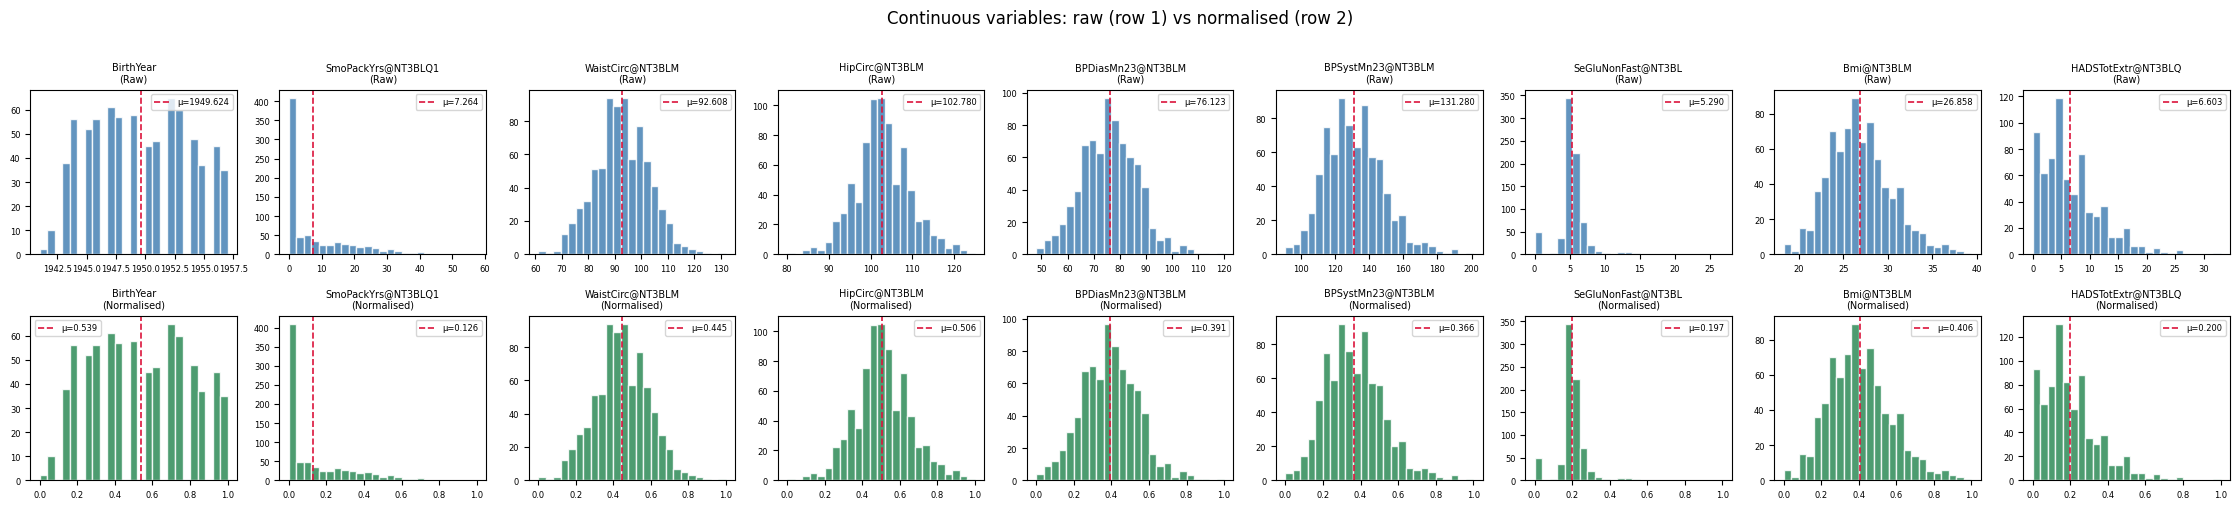

In [96]:
ncols = len(CONTINUOUS)
fig, axes = plt.subplots(2, ncols, figsize=(2.5 * ncols, 5))

for col, ax_r, ax_n in zip(CONTINUOUS, axes[0], axes[1]):
    r_data = raw[col].dropna()
    n_data = norm[col].dropna()

    for ax, data, color, label in [
        (ax_r, r_data, 'steelblue', 'Raw'),
        (ax_n, n_data, 'seagreen',  'Normalised'),
    ]:
        ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(data.mean(), color='crimson', linestyle='--', lw=1.2,
                   label=f'μ={data.mean():.3f}')
        ax.set_title(f"{col[:18]}\n({label})", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.legend(fontsize=6)

plt.suptitle('Continuous variables: raw (row 1) vs normalised (row 2)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/norm_continuous_compare.png', dpi=150, bbox_inches='tight')
plt.show()

### Normalised continuous statistics

In [97]:
norm_stats = norm[CONTINUOUS].agg(['min','max','mean','median','std','var']).round(4)
print("All min ≈ 0, max ≈ 1 — distribution shape preserved.")
display(norm_stats.T.rename(columns=str.title))

All min ≈ 0, max ≈ 1 — distribution shape preserved.


,Min,Max,Mean,Median,Std,Var
BirthYear,0.0,1.0,0.5390,0.5000,0.2613,0.0683
SmoPackYrs@NT3BLQ1,0.0,1.0,0.1263,0.0261,0.1776,0.0315
WaistCirc@NT3BLM,0.0,1.0,0.4452,0.4507,0.1432,0.0205
HipCirc@NT3BLM,0.0,1.0,0.5062,0.5111,0.1456,0.0212
BPDiasMn23@NT3BLM,0.0,1.0,0.3906,0.3889,0.1474,0.0217
BPSystMn23@NT3BLM,0.0,1.0,0.3662,0.3545,0.1521,0.0231
SeGluNonFast@NT3BLM,0.0,1.0,0.1974,0.1940,0.0797,0.0063
Bmi@NT3BLM,0.0,1.0,0.4056,0.3934,0.1665,0.0277
HADSTotExtr@NT3BLQ2,0.0,1.0,0.1997,0.1818,0.1487,0.0221


---
## Part 3 — Feature-Wise Split Analysis

Train / val / test ids are loaded from `data/metadata/splits.json`. All distributions below
are over the **normalised** values — what the model actually sees, joined with FastSurfer
features via `CombinedMetadataUtils.combine()`.

### Continuous variables — quantile bin boundaries (stratification groups)

`_build_label_matrix` bins each continuous variable with `pd.qcut(q=4)`, producing four equal-frequency groups. 
The dashed lines below show the three interior bin edges; shaded regions correspond to the four stratification bins (Bin 0–3) 
that become binary indicator columns in the label matrix.

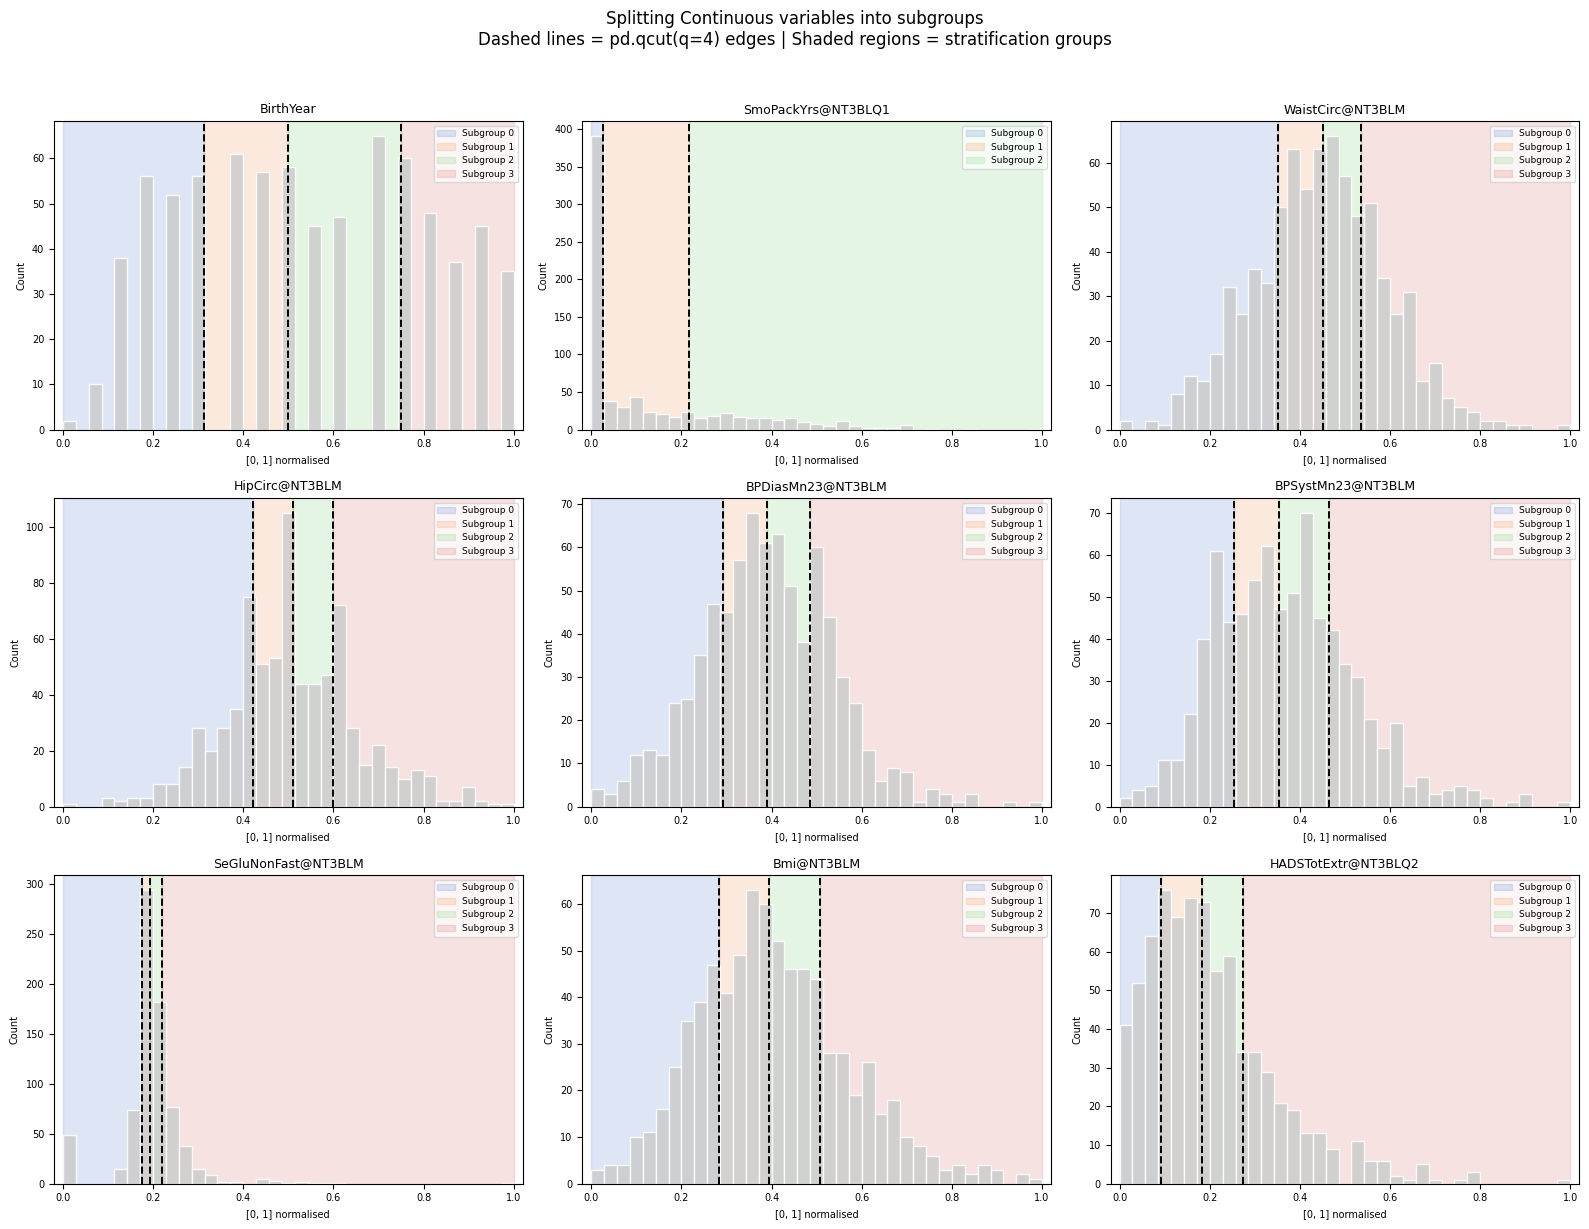

In [98]:
bin_colors = ['#4878d0', '#ee854a', '#6acc65', '#d65f5f']
bin_labels = ['Subgroup 0', 'Subgroup 1', 'Subgroup 2', 'Subgroup 3']

ncols = 3
nrows = (len(CONTINUOUS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))

for ax, col in zip(axes.flat, CONTINUOUS):
    data = norm[col].dropna()
    _, edges = pd.qcut(data, q=4, retbins=True, duplicates='drop')
    n_bins = len(edges) - 1

    ax.hist(data, bins=35, color='#cccccc', edgecolor='white', alpha=0.85, zorder=1)
    for i in range(n_bins):
        ax.axvspan(edges[i], edges[i + 1], alpha=0.18, color=bin_colors[i],
                   label=bin_labels[i], zorder=0)
    for edge in edges[1:-1]:
        ax.axvline(edge, color='black', linestyle='--', lw=1.4, zorder=3)

    ax.set_title(col, fontsize=9)
    ax.set_xlabel('[0, 1] normalised', fontsize=7)
    ax.set_ylabel('Count', fontsize=7)
    ax.set_xlim(-0.02, 1.02)
    ax.legend(fontsize=6.5, loc='upper right', framealpha=0.7)
    ax.tick_params(labelsize=7)

for ax in axes.flat[len(CONTINUOUS):]:
    ax.set_visible(False)

plt.suptitle('Splitting Continuous variables into subgroups\n'
             'Dashed lines = pd.qcut(q=4) edges | Shaded regions = stratification groups',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/norm_continuous_qcut_bins.png', dpi=150, bbox_inches='tight')
plt.show()

### One-hot encoded categoricals

Each categorical variable is split into binary indicator columns.
The **mean** of each column equals the **fraction** of subjects in that category — identical to the raw percentage, just encoded as a number in [0, 1].

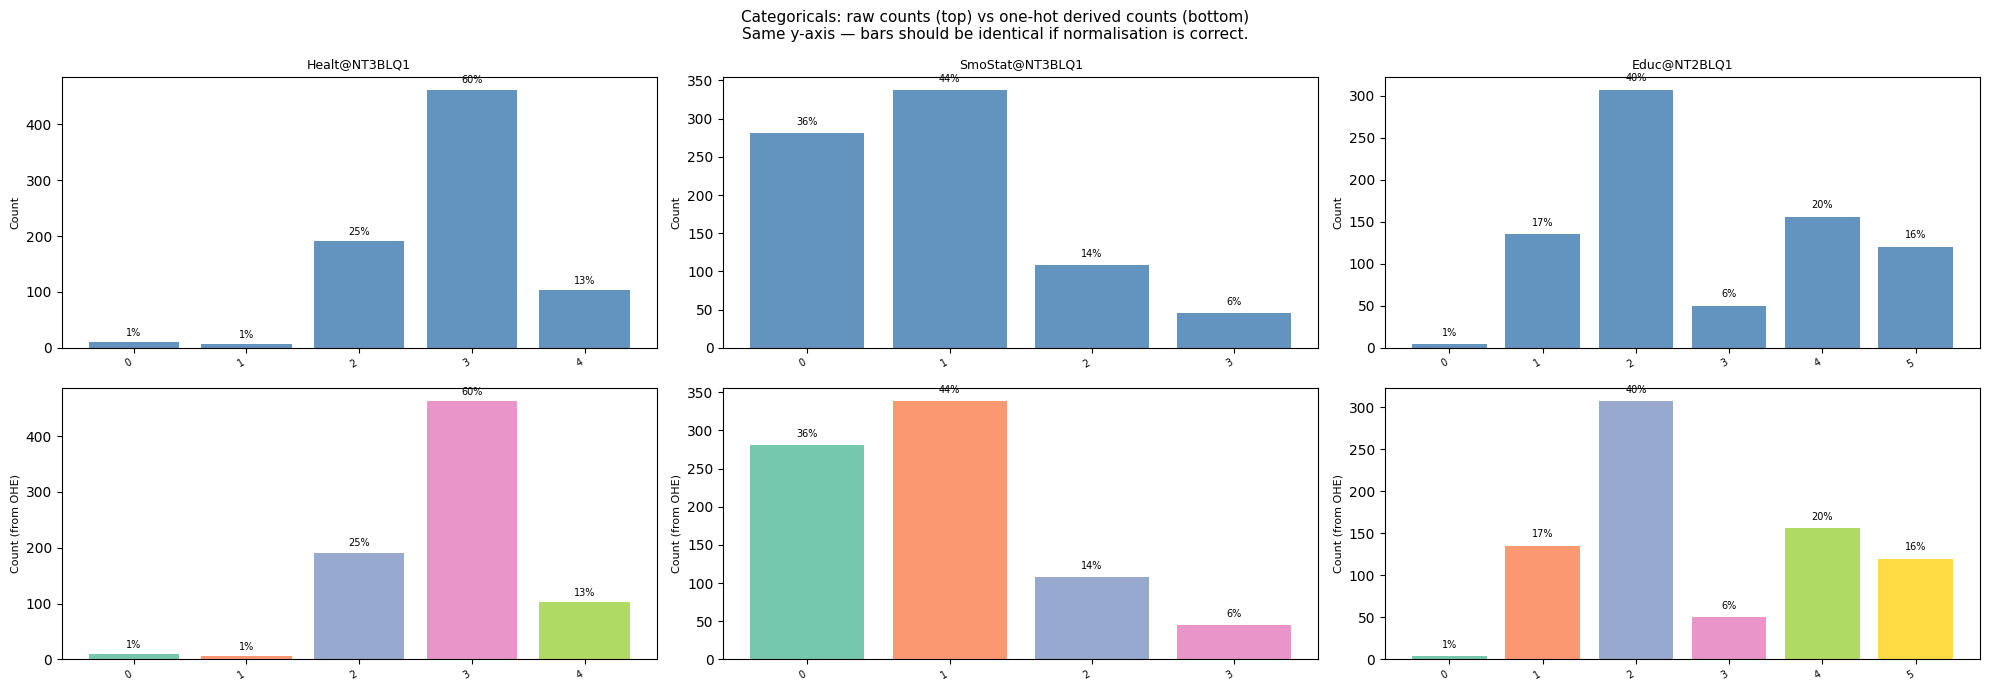

In [99]:
n_cats = len(CATEGORICAL)
n_subj = len(norm)
fig, axes = plt.subplots(2, n_cats, figsize=(20, 7))

for col_i, cat in enumerate(CATEGORICAL):
    ohe_cols = ohe_groups[cat]
    labels   = [c.replace(cat + '_','') for c in ohe_cols]
    raw_vc   = raw[cat].dropna().value_counts().sort_index()
    means    = norm[ohe_cols].mean().values
    counts   = means * n_subj

    ax_top = axes[0, col_i]
    ax_top.bar(range(len(raw_vc)), raw_vc.values, color='steelblue', alpha=0.85)
    ax_top.set_xticks(range(len(raw_vc)))
    ax_top.set_xticklabels([str(v) for v in raw_vc.index],
                            rotation=30, ha='right', fontsize=7)
    ax_top.set_title(cat, fontsize=9)
    ax_top.set_ylabel('Count', fontsize=8)
    raw_total = raw_vc.sum()
    for i, v in enumerate(raw_vc.values):
        ax_top.text(i, v + raw_total*0.01, f'{v/raw_total*100:.0f}%',
                    ha='center', va='bottom', fontsize=7)

    ax_bot = axes[1, col_i]
    bars = ax_bot.bar(range(len(labels)), counts,
                      color=plt.cm.Set2.colors[:len(labels)], alpha=0.9)
    ax_bot.set_xticks(range(len(labels)))
    ax_bot.set_xticklabels(labels, rotation=30, ha='right', fontsize=7)
    ax_bot.set_ylabel('Count (from OHE)', fontsize=8)
    ax_bot.set_ylim(0, ax_top.get_ylim()[1])
    for bar, c_val, m in zip(bars, counts, means):
        ax_bot.text(bar.get_x() + bar.get_width()/2, c_val + n_subj*0.01,
                    f'{m*100:.0f}%', ha='center', va='bottom', fontsize=7)

plt.suptitle('Categoricals: raw counts (top) vs one-hot derived counts (bottom)\n'
             'Same y-axis — bars should be identical if normalisation is correct.',
             fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/norm_categorical_ohe.png', dpi=150, bbox_inches='tight')
plt.show()

In [100]:
print("One-hot column statistics (mean = fraction, std reflects imbalance)\n")
for cat in CATEGORICAL:
    ohe_cols = ohe_groups[cat]
    tbl = norm[ohe_cols].agg(['mean','std','min','max']).round(4)
    tbl.columns = [c.replace(cat + '_','') for c in tbl.columns]
    tbl.index.name = cat
    display(tbl)
    print()

One-hot column statistics (mean = fraction, std reflects imbalance)



,0,1,2,3,4
Healt@NT3BLQ1,,,,,
mean,0.0130,0.0078,0.2474,0.5984,0.1334
std,0.1131,0.0879,0.4318,0.4905,0.3402
min,0.0000,0.0000,0.0000,0.0000,0.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000


,0,1,2,3
SmoStat@NT3BLQ1,,,,
mean,0.3640,0.4378,0.1399,0.0583
std,0.4815,0.4964,0.3471,0.2344
min,0.0000,0.0000,0.0000,0.0000
max,1.0000,1.0000,1.0000,1.0000


,0,1,2,3,4,5
Educ@NT2BLQ1,,,,,,
mean,0.0052,0.1749,0.3977,0.0648,0.2021,0.1554
std,0.0718,0.3801,0.4897,0.2463,0.4018,0.3626
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [101]:
train_ids = [str(i).zfill(5) for i in _splits['train']]
val_ids   = [str(i).zfill(5) for i in _splits['val']]
test_ids  = [str(i).zfill(5) for i in _splits['test']]

# Load combined dataset via CombinedMetadataUtils (merges health + fastsurfer normalized data)
loader = CombinedMetadataUtils()
loader.combine(overwrite=True)  # rebuild from current normalized CSVs
combined = pd.read_csv(loader.csv_path, dtype={'hunt_id': str})
combined['hunt_id'] = combined['hunt_id'].astype(str).str.zfill(5)

id_to_split = {}
id_to_split.update({i: 'Train'      for i in train_ids})
id_to_split.update({i: 'Validation' for i in val_ids})
id_to_split.update({i: 'Test'       for i in test_ids})

norm_s = combined.copy()
norm_s['split'] = norm_s['hunt_id'].map(id_to_split)
norm_s = norm_s.dropna(subset=['split'])
norm_s['split'] = pd.Categorical(norm_s['split'],
                                  categories=SPLIT_NAMES, ordered=True)

totals = norm_s['split'].value_counts().sort_index()
print(f"Seed: {SEED}  |  Total mapped subjects: {len(norm_s)}")
for name, n in totals.items():
    print(f"  {name:<12} {n:>4}  ({n/len(norm_s)*100:.1f}%)")

[combine] health=772  fastsurfer=731  overlap=731  dropped=41
[combine] 731 subjects × 39 features → data/metadata/metadata_combined.csv
Seed: 69  |  Total mapped subjects: 703
  Train         483  (68.7%)
  Validation    107  (15.2%)
  Test          113  (16.1%)


### Continuous variables — per-split distributions (normalised, [0, 1])

3 × 3 grid of boxplots (one per variable, with Train / Val / Test side-by-side).
Values near 0 / 1 are the extremes of that feature across the full cohort.

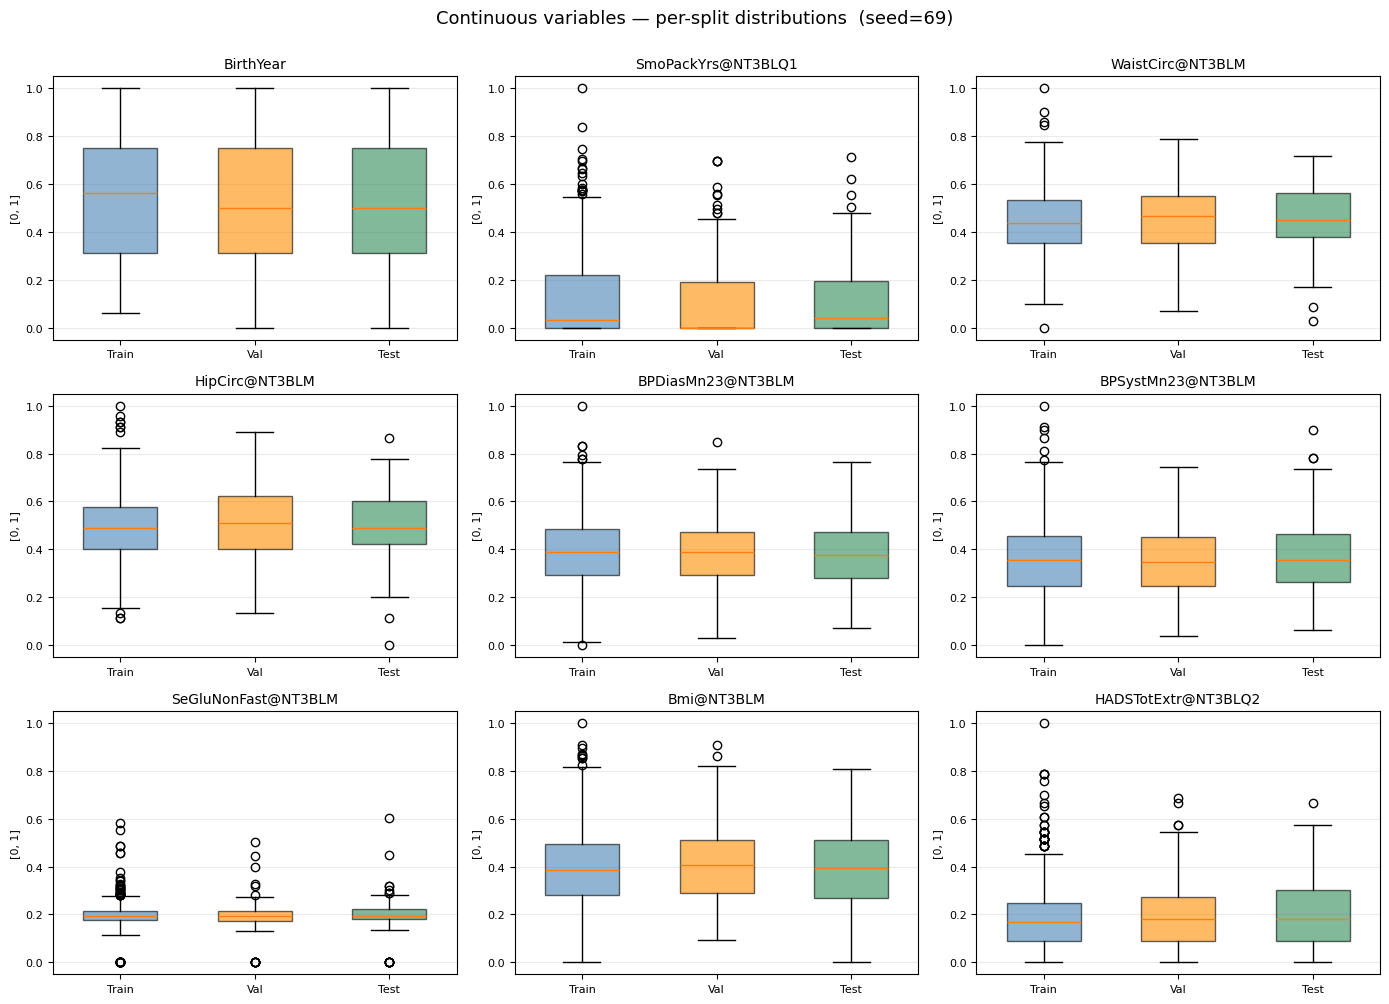

In [102]:
ncols = 3
nrows = 3  # 9 continuous variables fit exactly in a 3x3 grid
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 10))

for ax, col in zip(axes.flat, CONTINUOUS):
    data_by_split = [norm_s[norm_s['split']==s][col].dropna() for s in SPLIT_NAMES]
    bp = ax.boxplot(data_by_split, tick_labels=['Train', 'Val', 'Test'],
                    patch_artist=True, widths=0.55)
    for patch, color in zip(bp['boxes'], SPLIT_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('[0, 1]', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(axis='y', alpha=0.25)

# Hide any leftover axes (none expected for 9 vars / 9 cells)
for ax in axes.flat[len(CONTINUOUS):]:
    ax.set_visible(False)

plt.suptitle(f'Continuous variables — per-split distributions  (seed={SEED})',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/split_continuous.png', dpi=150, bbox_inches='tight')
plt.show()


In [103]:
stat_rows = []
for col in CONTINUOUS:
    for split_name in SPLIT_NAMES:
        s = norm_s[norm_s['split']==split_name][col].dropna()
        stat_rows.append({'Variable': col, 'Split': split_name,
                          'Min': s.min(), 'Max': s.max(),
                          'Mean': s.mean(), 'Median': s.median(),
                          'Std': s.std(), 'Var': s.var()})
display(pd.DataFrame(stat_rows).set_index(['Variable', 'Split']).round(4))


Min     Max    Mean  Median     Std     Var
Variable            Split                                                     
BirthYear           Train       0.0625  1.0000  0.5454  0.5625  0.2637  0.0695
                    Validation  0.0000  1.0000  0.5368  0.5000  0.2594  0.0673
                    Test        0.0000  1.0000  0.5299  0.5000  0.2621  0.0687
SmoPackYrs@NT3BLQ1  Train       0.0000  1.0000  0.1280  0.0313  0.1782  0.0318
                    Validation  0.0000  0.6957  0.1246  0.0000  0.1944  0.0378
                    Test        0.0000  0.7130  0.1203  0.0417  0.1639  0.0269
WaistCirc@NT3BLM    Train       0.0000  1.0000  0.4366  0.4366  0.1428  0.0204
                    Validation  0.0704  0.7887  0.4607  0.4648  0.1438  0.0207
                    Test        0.0282  0.7183  0.4458  0.4507  0.1400  0.0196
HipCirc@NT3BLM      Train       0.1111  1.0000  0.5001  0.4889  0.1449  0.0210
                    Validation  0.1333  0.8889  0.5217  0.5111  0.1540  0.0237
                    Test        0.0000  0.8667  0.4944  0.4889  0.1439  0.0207
BPDiasMn23@NT3BLM   Train       0.0000  1.0000  0.3913  0.3889  0.1495  0.0223
                    Validation  0.0278  0.8472  0.3846  0.3889  0.1472  0.0217
                    Test        0.0694  0.7639  0.3824  0.3750  0.1377  0.0189
BPSystMn23@NT3BLM   Train       0.0000  1.0000  0.3636  0.3545  0.1508  0.0227
                    Validation  0.0364  0.7455  0.3549  0.3455  0.1504  0.0226
                    Test        0.0636  0.9000  0.3746  0.3545  0.1540  0.0237
SeGluNonFast@NT3BLM Train       0.0000  0.5821  0.1946  0.1940  0.0711  0.0051
                    Validation  0.0000  0.5037  0.1936  0.1940  0.0750  0.0056
                    Test        0.0000  0.6045  0.1988  0.1940  0.0759  0.0058
Bmi@NT3BLM          Train       0.0000  1.0000  0.3989  0.3839  0.1667  0.0278
                    Validation  0.0948  0.9100  0.4188  0.4076  0.1629  0.0265
                    Test        0.0000  0.8057  0.3955  0.3934  0.1627  0.0265
HADSTotExtr@NT3BLQ2 Train       0.0000  1.0000  0.1932  0.1697  0.1506  0.0227
                    Validation  0.0000  0.6848  0.2040  0.1818  0.1521  0.0231
                    Test        0.0000  0.6667  0.2033  0.1818  0.1379  0.0190

### One-hot encoded categoricals — composition per split

- **`split_categorical_within.png`** — % within split: of subjects in each split,
  what fraction carries each category? All three bars should look similar (stratification quality check).
- **`split_categorical_allocation.png`** — % allocated across splits: of all subjects with a given
  category, what fraction landed in each split? Dashed lines = target 70 / 15 / 15.

In [ ]:
# Figure 1 — % within each split (grouped by category level)
fig, axes = plt.subplots(len(CATEGORICAL), 1, figsize=(10, 4 * len(CATEGORICAL)))
for ax, cat in zip(axes, CATEGORICAL):
    ohe_cols = ohe_groups[cat]
    labels   = [c.replace(cat + '_', '') for c in ohe_cols]

    x      = np.arange(len(SPLIT_NAMES))
    width  = 0.8 / len(ohe_cols)
    colors = plt.cm.Set2.colors

    for j, (col, label) in enumerate(zip(ohe_cols, labels)):
        pcts = [norm_s[norm_s['split']==s][col].mean()*100 for s in SPLIT_NAMES]
        ax.bar(x + j*width - width*len(ohe_cols)/2, pcts, width,
               label=label, color=colors[j], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(SPLIT_NAMES, fontsize=10)
    ax.set_title(cat, fontsize=11)
    ax.set_ylabel('% within split', fontsize=10)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=9, loc='upper right')
    ax.tick_params(labelsize=9)
    ax.grid(axis='y', alpha=0.25)

plt.suptitle(f'One-hot categoricals — % within each split  (seed={SEED})', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/split_categorical_within.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Figure 2 — % of each category allocated to each split
ref_pcts = [TRAIN_SPLIT*100, VAL_SPLIT*100, (1-TRAIN_SPLIT-VAL_SPLIT)*100]
fig, axes = plt.subplots(len(CATEGORICAL), 1, figsize=(10, 4 * len(CATEGORICAL)))

for ax, cat in zip(axes, CATEGORICAL):
    ohe_cols = ohe_groups[cat]
    labels   = [c.replace(cat + '_', '') for c in ohe_cols]

    x     = np.arange(len(labels))
    width = 0.8 / len(SPLIT_NAMES)

    for k, (split_name, scolor) in enumerate(zip(SPLIT_NAMES, SPLIT_COLORS)):
        sub = norm_s[norm_s['split']==split_name]
        pcts = []
        for col in ohe_cols:
            n_col_total = (norm_s[col] == 1).sum()
            n_col_split = (sub[col] == 1).sum()
            pcts.append(n_col_split / n_col_total * 100 if n_col_total else 0)
        ax.bar(x + k*width - width*len(SPLIT_NAMES)/2, pcts, width,
               label=split_name, color=scolor, alpha=0.8)

    for pct, color in zip(ref_pcts, SPLIT_COLORS):
        ax.axhline(pct, color=color, linestyle='--', lw=0.9, alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_title(cat, fontsize=11)
    ax.set_ylabel('% allocated to split', fontsize=10)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=9, loc='upper right')
    ax.tick_params(labelsize=9)
    ax.grid(axis='y', alpha=0.25)

plt.suptitle(f'One-hot categoricals — split allocation per category  (seed={SEED})\n'
             f'Dashed = target {TRAIN_SPLIT*100:.0f}/{VAL_SPLIT*100:.0f}/'
             f'{(1-TRAIN_SPLIT-VAL_SPLIT)*100:.0f}%',
             fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/split_categorical_allocation.png', dpi=150, bbox_inches='tight')
plt.show()


In [106]:
print("One-hot column means per split  (values = % of split)\n")
for cat in CATEGORICAL:
    ohe_cols  = ohe_groups[cat]
    short_lbl = [c.replace(cat + '_', '') for c in ohe_cols]
    tbl = norm_s.groupby('split', observed=True)[ohe_cols].mean().round(4) * 100
    tbl.columns = short_lbl
    tbl['Total subjects'] = norm_s.groupby('split', observed=True).size()
    print(f"── {cat} ──")
    display(tbl)
    print()


One-hot column means per split  (values = % of split)

── Healt@NT3BLQ1 ──


,0,1,2,3,4,Total subjects
split,,,,,,
Train,1.24,0.62,23.19,60.87,14.08,483
Validation,0.93,0.93,28.04,57.01,13.08,107
Test,0.88,0.88,25.66,59.29,13.27,113



── SmoStat@NT3BLQ1 ──


,0,1,2,3,Total subjects
split,,,,,
Train,37.27,42.24,14.70,5.80,483
Validation,35.51,44.86,14.02,5.61,107
Test,32.74,48.67,13.27,5.31,113



── Educ@NT2BLQ1 ──


,0,1,2,3,4,5,Total subjects
split,,,,,,,
Train,0.41,17.18,38.51,7.04,21.12,15.73,483
Validation,0.00,16.82,38.32,6.54,17.76,20.56,107
Test,0.88,15.93,41.59,6.19,20.35,15.04,113


### Binary variables — class counts per split

For each binary variable, a 1 × 3 panel: x-axis shows the two class values (0 and 1),
with grouped bars for Train / Validation / Test, and y-axis = subject count.
Saved as `split_binary.png`.

In [ ]:
fig, axes = plt.subplots(len(BINARY), 1, figsize=(8, 4 * len(BINARY)))

classes = [0, 1]
x       = np.arange(len(classes))
width   = 0.8 / len(SPLIT_NAMES)

for ax, col in zip(axes, BINARY):
    for k, (split_name, scolor) in enumerate(zip(SPLIT_NAMES, SPLIT_COLORS)):
        sub = norm_s[norm_s['split']==split_name]
        counts = [int((sub[col] == cls).sum()) for cls in classes]
        bars = ax.bar(x + k*width - width*len(SPLIT_NAMES)/2, counts, width,
                      label=split_name, color=scolor, alpha=0.85)
        for bar, c_val in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                    f'{c_val}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(['0', '1'], fontsize=11)
    ax.set_xlabel('Class value', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(col, fontsize=11)
    ax.tick_params(labelsize=9)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.25)

plt.suptitle(f'Binary variables — class counts per split  (seed={SEED})',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/split_binary.png', dpi=150, bbox_inches='tight')
plt.show()


In [108]:
print("Binary variables per split  (counts and % within split)\n")
for col in BINARY:
    rows = []
    for split_name in SPLIT_NAMES:
        sub = norm_s[norm_s['split']==split_name]
        n0 = int((sub[col] == 0).sum())
        n1 = int((sub[col] == 1).sum())
        n  = n0 + n1
        rows.append({
            'Split': split_name,
            '# = 0': n0,
            '# = 1': n1,
            '% = 1': round(n1 / n * 100, 2) if n else 0.0,
            'Total': n,
        })
    print(f"── {col} ──")
    display(pd.DataFrame(rows).set_index('Split'))
    print()


Binary variables per split  (counts and % within split)

── Sex ──


,# = 0,# = 1,% = 1,Total
Split,,,,
Train,256,227,47.00,483
Validation,61,46,42.99,107
Test,57,56,49.56,113



── DiaEv@NT3BLQ1 ──


,# = 0,# = 1,% = 1,Total
Split,,,,
Train,468,15,3.11,483
Validation,104,3,2.80,107
Test,110,3,2.65,113



── WorCu@NT3BLI ──


,# = 0,# = 1,% = 1,Total
Split,,,,
Train,64,419,86.75,483
Validation,19,88,82.24,107
Test,17,96,84.96,113
